In [1]:
from bias import Bias

In [2]:
from observations import Observations
from models_physical import VdP


obs = Observations(model=VdP, 
                    t_start=2.0, 
                    t_stop=2.5, 
                    Nt_obs=50, 
                    add_noise=True,
                    Nq=2,
                    noise_type='gauss, add',
                    noise_level=0.1,
                    manual_bias='linear'
                    )


...Applying manual bias: linear
...Adding noise: gauss, add with level 0.1.
OK: Observations initialized.


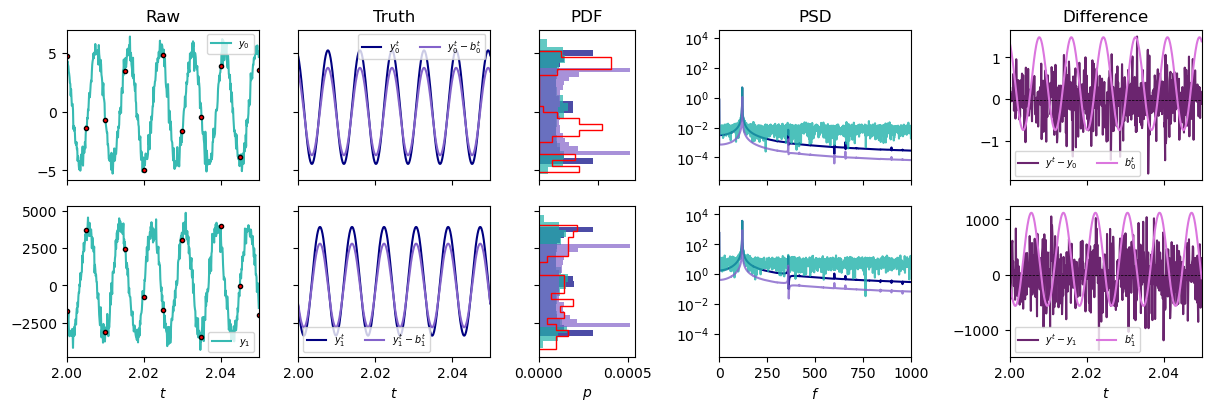

In [3]:

Observations.plot_truth(obs, f_max=1000, window=.05)

We want to model the truth $y^{true}$ using a reduced order model, which may be biased. In this twin experiment case, the ROM is  show in the figure above as $y^{true}-b^{true}$.


To infer the bias $b^{true}$ from the obsdervation data $d$ (red dots) without knowing the truth $y^{true}$, we need to make some assumtions. First, we will assume that we have a model of the system which gives some estimate of the system as 
$$
y^{rom}(t) = y^{true}(t) + b^{true}(t) + \varepsilon_y
$$
and the observations 
$$
d(t^{obs}) = y^{true}(t^{obs}) + \varepsilon_{obs}, 
$$
where $\varepsilon$ is noise. 

In [4]:
from utils import load_from_pickle_file
dat = load_from_pickle_file('/storage0/anovoama/codes/real_public/results/tutorials/VdP/Tutorial_05_bias_training_data')

In [5]:
dat, dat['data'].shape

({'bayesian_update': False,
  'upsample': 4,
  'biased_observations': False,
  'data': array([[[ 4.57710764e-01,  1.15457240e+03],
          [ 4.76167719e-01,  9.75248363e+02],
          [ 2.81073837e-01,  7.09226137e+02],
          ...,
          [ 1.21321674e+00, -5.34993349e+02],
          [ 1.68348632e+00,  2.23435908e+02],
          [ 7.33600393e-01,  9.93306283e+01]],
  
         [[-2.46809531e+00,  4.36078070e+03],
          [-2.12116099e+00,  4.33955200e+03],
          [-1.97284998e+00,  4.21153554e+03],
          ...,
          [ 6.24619145e+00, -1.34628606e+03],
          [ 6.62066472e+00, -8.73697399e+02],
          [ 5.54670648e+00, -1.27777656e+03]]]),
  'observed_idx': array([0, 1])},
 (2, 4200, 2))

In [11]:
from bias_data_driven import ESN_bias
from utils import set_working_directories 
from pathlib import Path

# First, initialize a ROM 
rom = VdP(Nq=2
    )


results_dir = set_working_directories('VdP')[1]

training_data_filename = Path(results_dir) / 'Tutorial_05_bias_training_data2'


# Then, initialize a Bias object using the ROM and the Observations
bias = ESN_bias(rom=rom,
                reference_data=obs,
                t_min=0.5,
                t_max=2.0,
                training_data_filename=training_data_filename,
                # Parameters for training data generation (if no file found or loading fails)
                std_phi=0.1,
                std_alpha=0.1,
                biased_observations=False,
                # Other parameters for the bias model can be added here as needed
                N_units=50,
                auto_save=True,
                N_func_evals=20,
                N_grid=4,
                t_train=0.2, 
                t_val=0.02,
                upsample=4
                )


✓ Found matching config: 23fd19da31841c04
Configuration loaded from ...config/esn_configs/23fd19da31841c04/esn_config.yaml


In [8]:
bias.print_bias_parameters()


 ---------------- Bias model parameters --------------- 
	 Bias class name: ESN_bias
	 bayesian_update = False
	 biased_observations = False
	 upsample = 4
	 Model class name: ESN_model
	 N_units = 50
	 N_wash = 5
	 rho = 0.200000
	 sigma_in = 1.348339
	 update_reservoir = True
	 update_state = True
	 upsample = 4
